# Regression on AML data

## Time-dependent GMM via Spline-regressed parameters
Weighted 2D point clouds

LOOCV for evaluation

Sample-weighted GMM using sample_weight in sklearn

In [1]:
import numpy as np
import pickle

import sys
module_paths = ['']
for path in module_paths :
    if path not in sys.path:
        sys.path.append(path)

from utils_load_PHloc import (extract_PH_heatmaps_single_sample,
contour_heatmaps,
collect_paired_crit_sizes,
collect_indiv_crit_sizes)

from utils_load_PHloc import datasets_of_interest, injected_datasets_of_interest, levels_of_interest
from Bio import Phylo, AlignIO
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet, fcluster
from scipy.spatial.distance import pdist
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances
from sklearn.cluster import AgglomerativeClustering

# folder where you put the PHloc files
PH_folder = '' 

# choose desired anatomy: 'knee', 'long', 'both' (which is a merge of the birth-death points)
anatomy = 'knee'

# load file
filepath = PH_folder + 'PH_all_{}.pkl'.format(anatomy)
print('I will load',filepath)
PH_all_datasets = pickle.load(open(filepath, 'rb'))


[KeOps] Warning : Cuda libraries were not detected on the system ; using cpu only mode
I will load PH_all_knee.pkl


In [13]:
# threshold value
THR = .5

# generate a new dictionary for truncated datasets
truncated_PH_all_datasets = {}
for i in datasets_of_interest:
    diagram = PH_all_datasets[i]
    truncated_PH_all_datasets[i] = diagram[diagram[:,1] >= diagram[:,0] + THR]
    
# print size of the diagrams
for i in datasets_of_interest:
    diagram1 = PH_all_datasets[i]
    diagram2 = truncated_PH_all_datasets[i]
print("done")

names = [injected_datasets_of_interest[i]+"_"+[str(x) for x in datasets_of_interest][i] for i in range(27)]

labels = ['CTRL_0%(1)', 'CTRL_0%(2)', 'CTRL_0%(3)', 'CTRL_0%(4)', 
          'U937_1%(1)', 'U937_1%(2)', 'U937_7%', 'U937_8%', 'U937_10%(1)', 'U937_10%(2)', 'U937_10%(3)', 
          'HL60_23%', 'HL60_25%(1)', 'HL60_25%(2)', 
          'P1_10%', 'P1_40%', 'P1_44%', 'P1_51%', 'P1_60%', 'P1_76%', 
          'P2_59%', 'P2_88%', 'P2_90%', 
          'MNC_53%', 'MNC_67%', 'MNC_75%', 'MNC_86%']

phases_of_interest_int = [0,0,0,0,
         1,1,1,1,1,1,1,
         1,1,1,
         1,2,2,2,2,1,
         2,2,2,
         1,2,2,2]
 
phases_of_interest = ["O","O","O","O",
         "I","I","I","I","I","I","I",
         "I","I","I",
         "I","II","II","II","II","I",
         "II","II","II",
         "I","II","II","II"]

name_phase = [labels[i]+" [Phase "+phases_of_interest[i]+"]" for i in range(27)]

# assign colours to the labels
# phase O = green; phase I = orange; phase II = red
colour_labels = []
for cat in phases_of_interest:
    if cat=="O":
        colour_labels.append("green")
    if cat=="I":
        colour_labels.append("orange")
    if cat=="II":
        colour_labels.append("red")
        
import matplotlib.pyplot as plt

################ PARAMETERS

# default values used: WEIGHTS = True (dirac masses weighted by persistence) ; SIGMA = .5

WEIGHTS = True
SIGMA = .5

# Binning parameters
XLIMS = np.array([[-15,0],[-10,10],[0,20]])
YLIMS = np.array([[-8,7],[-5,15],[0,20]])
NB_BINS_PER_SIDE = 100




done


In [21]:
pds = [truncated_PH_all_datasets[datasets_of_interest[i]] for i in range(27)]
pds0 = [x[x[:,2]==0,:2] for x in pds]
pds1 = [x[x[:,2]==1,:2] for x in pds]
pds2 = [x[x[:,2]==2,:2] for x in pds]

In [23]:
# data format: (time_i, points_i, weights_i)  
# time_i: float
# points_i: (N_i, 2) numpy array
# weights_i: (N_i,) numpy array
data_ph1 = [(datasets_of_interest[i], pds1[i], pds1[i][:,1]-pds1[i][:,0]) for i in range(27)]


In [25]:
import numpy as np
from sklearn.mixture import GaussianMixture
from scipy.interpolate import UnivariateSpline
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")


# --- Helper: Resample a single weighted point cloud ---
def resample_by_weights(X, weights, n_samples=None):
    n_samples = n_samples or len(X)
    p = weights / np.sum(weights)
    idx = np.random.choice(len(X), size=n_samples, replace=True, p=p)
    return X[idx]


# --- Helper: Fit GMM with optional resampling ---
def fit_gmm_weighted(X, weights=None, K=3, n_init=3, max_iter=200):
    if weights is not None:
        X = resample_by_weights(X, weights, n_samples=len(X))
    gmm = GaussianMixture(n_components=K, covariance_type='full', n_init=n_init, max_iter=max_iter)
    gmm.fit(X)
    return gmm


# --- Helper: Aggregate GMM means and weights ---
def extract_gmm_params(gmm):
    return gmm.means_, gmm.weights_


# --- Helper: Group identical time points and average ---
def average_by_time(times, all_means, all_weights, K):
    grouped = defaultdict(lambda: {'means': [], 'weights': []})
    for t, mu, pi in zip(times, all_means, all_weights):
        grouped[t]['means'].append(mu)
        grouped[t]['weights'].append(pi)

    unique_times = sorted(grouped.keys())
    averaged_means = []
    averaged_weights = []

    for t in unique_times:
        means_stack = np.stack(grouped[t]['means'])  # (n_samples, K, 2)
        weights_stack = np.stack(grouped[t]['weights'])  # (n_samples, K)
        averaged_means.append(means_stack.mean(axis=0))
        averaged_weights.append(weights_stack.mean(axis=0))

    return np.array(unique_times), averaged_means, averaged_weights


# --- Helper: Fit splines (supports jitter or averaging) ---
def fit_splines(times, all_means, all_weights, K=3, smooth=1.0, method='jitter'):
    if method == 'jitter':
        times = np.array(times) + np.random.uniform(0, 1e-4, len(times))
        sort_idx = np.argsort(times)
        times_sorted = np.array(times)[sort_idx]
        all_means_sorted = [all_means[i] for i in sort_idx]
        all_weights_sorted = [all_weights[i] for i in sort_idx]
    elif method == 'average':
        times_sorted, all_means_sorted, all_weights_sorted = average_by_time(times, all_means, all_weights, K)
    else:
        raise ValueError("method must be 'jitter' or 'average'")

    splines_mu = {
        k: [UnivariateSpline(times_sorted, [mu[k][0] for mu in all_means_sorted], s=smooth),
            UnivariateSpline(times_sorted, [mu[k][1] for mu in all_means_sorted], s=smooth)]
        for k in range(K)
    }

    splines_pi = {
        k: UnivariateSpline(times_sorted, [pi[k] for pi in all_weights_sorted], s=smooth)
        for k in range(K)
    }

    return splines_mu, splines_pi

def predict_time_from_likelihood(X, splines_mu, splines_pi, K, time_grid):
    best_t = None
    best_ll = -np.inf

    for t in time_grid:
        means = np.array([[splines_mu[k][0](t), splines_mu[k][1](t)] for k in range(K)])
        weights = np.array([splines_pi[k](t) for k in range(K)])
        weights /= weights.sum()

        try:
            gmm = GaussianMixture(n_components=K, covariance_type='full', init_params='kmeans', max_iter=1)
            gmm.means_init = means
            gmm.weights_init = weights
            gmm.fit(X)  # quick fit to assign covariances
            ll = gmm.score(X) * len(X)
            if ll > best_ll:
                best_ll = ll
                best_t = t
        except:
            continue

    return best_t

def loocv_worker_time_prediction(data, K, idx, smooth=1.0, method='jitter', time_grid=None):
    train_data = [data[i] for i in range(len(data)) if i != idx]
    test_data = data[idx]

    all_times, all_means, all_weights = [], [], []

    for t, X, w in train_data:
        gmm = fit_gmm_weighted(X, w, K)
        mu, pi = extract_gmm_params(gmm)
        all_times.append(t)
        all_means.append(mu)
        all_weights.append(pi)

    splines_mu, splines_pi = fit_splines(all_times, all_means, all_weights, K, smooth=smooth, method=method)

    t_test, X_test, w_test = test_data

    if time_grid is None:
        time_grid = np.linspace(min(all_times), max(all_times), 100)

    predicted_t = predict_time_from_likelihood(X_test, splines_mu, splines_pi, K, time_grid)

    return t_test, predicted_t

# --- Leave-one-out CV worker ---
def loocv_worker(data, K, idx, smooth=1.0, method='jitter'):
    train_data = [data[i] for i in range(len(data)) if i != idx]
    test_data = data[idx]
    all_times, all_means, all_weights = [], [], []

    for t, X, w in train_data:
        gmm = fit_gmm_weighted(X, w, K)
        mu, pi = extract_gmm_params(gmm)
        all_times.append(t)
        all_means.append(mu)
        all_weights.append(pi)

    splines_mu, splines_pi = fit_splines(all_times, all_means, all_weights, K, smooth=smooth, method=method)

    t_test, X_test, w_test = test_data
    predicted_means = np.array([[splines_mu[k][0](t_test), splines_mu[k][1](t_test)] for k in range(K)])
    predicted_weights = np.array([splines_pi[k](t_test) for k in range(K)])
    predicted_weights /= predicted_weights.sum()

    gmm_pred = GaussianMixture(n_components=K, covariance_type='full', init_params='kmeans')
    gmm_pred.means_init = predicted_means
    gmm_pred.weights_init = predicted_weights
    gmm_pred.fit(X_test)

    return {
        'test_idx': idx,
        'predicted_means': predicted_means,
        'predicted_weights': predicted_weights,
        'fitted_model': gmm_pred
    }


# --- Top-level function ---
def loocv_spline_gmm_weighted(data, K=3, smooth=1.0, method='jitter', n_jobs=-1):
    results = Parallel(n_jobs=n_jobs)(
        delayed(loocv_worker)(data, K, i, smooth=smooth, method=method)
        for i in tqdm(range(len(data)), desc="LOOCV")
    )
    return results

def loocv_predict_time_and_plot(data, K=3, smooth=1.0, method='jitter', n_jobs=-1):
    time_grid = np.linspace(min(t for t, _, _ in data), max(t for t, _, _ in data), 100)

    results = Parallel(n_jobs=n_jobs)(
        delayed(loocv_worker_time_prediction)(data, K, i, smooth=smooth, method=method, time_grid=time_grid)
        for i in tqdm(range(len(data)), desc="LOOCV Time Prediction")
    )

    actual_times, predicted_times = zip(*results)

    plt.figure(figsize=(6, 6))
    plt.scatter(actual_times, predicted_times, c='blue', label='Predicted')
    plt.plot(actual_times, actual_times, 'r--', label='Ideal')
    plt.xlabel('Actual Time')
    plt.ylabel('Predicted Time')
    plt.title('Spline-GMM Time Prediction via LOOCV')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return actual_times, predicted_times

LOOCV Time Prediction: 100%|██████████| 27/27 [03:22<00:00,  7.49s/it]


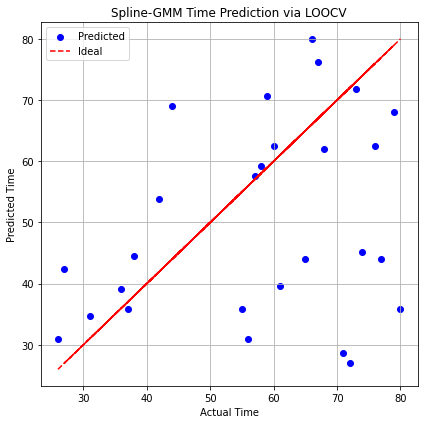

In [26]:
actual_times, predicted_times = loocv_predict_time_and_plot(data_ph1, K=3, method='average', n_jobs=4)
